In [5]:
!pip install xgboost -q

^C


In [3]:
# importinglibraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from xgboost import XGBClassifier

ModuleNotFoundError: No module named 'xgboost'

In [4]:
# import iris dataset with pandas
pf = sns.load_dataset('iris')
pf.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
# split the data into x and y
x = pf.drop('species', axis=1)
y = pf['species']
# split the data into train and test
x_train, x_test, y_train, y_test = train_test_split(x, y)


In [13]:
# encoding the target variable
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [14]:
# train the decision tree model 
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
# predict the test data
y_pred_dt = dt.predict(x_test)
# evaluate the model 
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
# also print precision and recall and f1 score
print('precision score')

Decision Tree Accuracy: 0.9473684210526315
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.93      0.93      0.93        14
           2       0.94      0.94      0.94        16

    accuracy                           0.95        38
   macro avg       0.96      0.96      0.96        38
weighted avg       0.95      0.95      0.95        38

Confusion Matrix:
 [[ 8  0  0]
 [ 0 13  1]
 [ 0  1 15]]
precision score


In [16]:
%%time
# train the random forest model 
rf = RandomForestClassifier()
rf.fit(x_train, y_train)
# predict the test data
y_pred_rf = rf.predict(x_test)
# evaluate the model
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
# also print precision and recall and f1 score
print('precision score:', precision_score(y_test, y_pred_rf, average='micro'))
print('recall score:', recall_score(y_test, y_pred_rf))
print('f1 score:', f1_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9473684210526315
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.93      0.93      0.93        14
           2       0.94      0.94      0.94        16

    accuracy                           0.95        38
   macro avg       0.96      0.96      0.96        38
weighted avg       0.95      0.95      0.95        38

Confusion Matrix:
 [[ 8  0  0]
 [ 0 13  1]
 [ 0  1 15]]
precision score: 0.9473684210526315


ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

NameError: name 'y_pred_xgb' is not defined

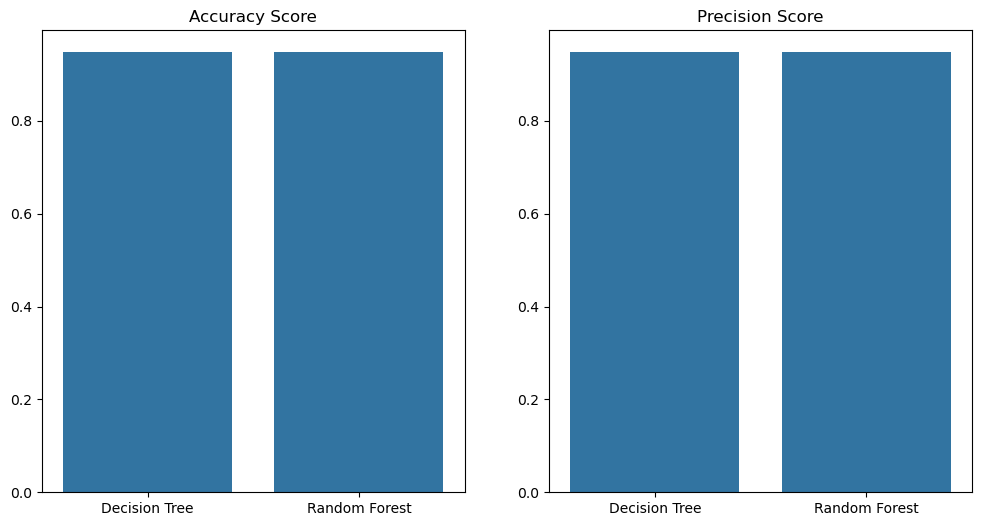

In [20]:
# make a bar plot showing each of the martix with respect to the model 
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.barplot(x=['Decision Tree', 'Random Forest'], y=[accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf)])
plt.title('Accuracy Score')
plt.subplot(1, 2, 2)
sns.barplot(x=['Decision Tree', 'Random Forest'], y=[precision_score(y_test, y_pred_dt, average='micro'), precision_score(y_test, y_pred_rf, average='micro')])
plt.title('Precision Score')

# now also make plot for the xgboost model 
plt.subplot(1, 2, 1)
sns.barplot(x=['Decision Tree', 'Random Forest', 'XGBoost'], y=[accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_xgb)])
plt.title('Accuracy Score')
plt.show()
